# Monotonicity Analysis of a Black-Box Model via Latin Hypercube Sampling
### MECH 559 - Systems Optimization - L03

Real design problems are rarely handed to you as clean closed-form objective and constraint
expressions. More often you have a **black-box** analysis code (an FEA solver, a CFD run, a
multibody simulation, a vendor-supplied performance map, ...) that you can *call* at a design
point and get numbers back -- with no visible equations and no gradients. This notebook shows
how to apply the **First and Second Monotonicity Principles** (MP1, MP2) from
Papalambros & Wilde, *Principles of Optimal Design*, Ch. 3, to exactly this situation, using
only:

1. a **Latin Hypercube (LHS)** sample of the design space,
2. **scatter plots with a binned trend line** of each black-box response versus each design
   variable (the only "visual" evidence we allow ourselves -- no derivatives!), and
3. a quantitative backup (Spearman rank correlation) to confirm what the plots suggest.

We then use MP1/MP2 to *predict* which requirements will be active at the optimum, before
ever running a formal optimizer -- and finally check the prediction with a derivative-free
black-box optimizer.

**Recap of the two principles**

> **MP1 (First Monotonicity Principle).** Every variable that appears *increasingly* in a
> well-constrained objective must be bounded below by at least one *nonincreasing* active
> constraint (symmetrically for a decreasing objective variable and an upper bound). If only
> one constraint can supply that bound, it is **critical** and must be active.

> **MP2 (Second Monotonicity Principle).** A variable that does **not** appear in the
> objective at all must still be bounded **both** above and below, or it could run away to
> $0$ or $\infty$ without the objective "noticing".

## Learning objectives

By the end, you should be able to:

1. Generate a Latin Hypercube sample over a multi-dimensional design space.
2. Screen a black-box model's monotonicity *visually*, from scatter + trend plots of sampled
   responses, without ever seeing (or needing) a closed-form expression or a derivative.
3. Back up a visual monotonicity call with a simple rank-correlation statistic.
4. Apply MP1 to objective variables and MP2 to nonobjective variables using only this
   sampled evidence, and predict which constraints will be active.
5. Verify the prediction with an independent, derivative-free (black-box-compatible)
   numerical optimizer.

> **Classroom rhythm:** Pause at each **Predict** prompt before revealing the plot.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.optimize import differential_evolution

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"sample": "#264653", "trend": "#D1495B", "optimum": "#EDAE49"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")

Optional widgets available: True


---
## 1. The black-box design problem: a flywheel energy-storage rotor

Imagine a rotordynamics group hands you a compiled simulator for a solid steel flywheel rotor
(outer radius $R$, axial width $w$, spin speed $\omega$). You can call it at any design and it
returns three numbers -- **mass**, **stored kinetic energy**, and **peak stress** -- with
realistic simulation noise on top. You are *not* given the equations inside.

**Design variables**

| symbol | meaning | range |
|---|---|---|
| $R$ | rotor outer radius [m] | $0.05 \le R \le 0.30$ |
| $w$ | rotor axial width [m] | $0.01 \le w \le 0.10$ |
| $\omega$ | spin speed [rad/s] | $200 \le \omega \le 3000$ |

**Objective** -- minimize rotor mass (material cost): $\min\; \text{mass}(R, w, \omega)$

**Requirements** (evaluated by the same black-box call)

* stored energy must meet the duty-cycle requirement: $\text{energy} \ge E_{\text{req}} = 60\,\text{kJ}$
* peak stress must stay under the material limit: $\text{stress} \le \sigma_{\text{allow}} = 300\,\text{MPa}$
* the side bounds on $R,w,\omega$ above also apply

We will *not* look inside `black_box()` for the reasoning below -- only at its sampled outputs.

In [3]:
# ---- "hidden" simulator parameters (a real black box would not expose these) ----
rho = 7800.0        # kg/m^3, steel density
nu = 0.3             # Poisson ratio
c_sigma = (3 + nu) / 8.0

E_req = 6.0e4        # J, minimum stored kinetic energy
sigma_allow = 300e6  # Pa, allowable stress

R_min, R_max = 0.05, 0.30      # m
w_min, w_max = 0.01, 0.10      # m
om_min, om_max = 200.0, 3000.0  # rad/s

var_names = ["R", "w", "omega"]
lo = [R_min, w_min, om_min]
hi = [R_max, w_max, om_max]
NOISE = 0.02  # 2% relative simulator noise, like a real solver's numerical tolerance


def black_box(X, generator=None, noise=NOISE):
    """Stand-in for an opaque rotordynamics/FEA simulator: given rows [R, w, omega]
    it returns mass, stored energy, and peak stress -- no formulas exposed to the caller."""
    if generator is None:
        generator = np.random.default_rng()
    X = np.atleast_2d(X)
    R, w, om = X[:, 0], X[:, 1], X[:, 2]
    mass = rho * np.pi * R**2 * w
    energy = 0.25 * rho * np.pi * R**4 * w * om**2
    stress = c_sigma * rho * om**2 * R**2
    out = {}
    for name, val in [("mass", mass), ("energy", energy), ("stress", stress)]:
        out[name] = val * (1.0 + noise * generator.standard_normal(val.shape))
    return out


smoke_test = black_box(np.array([[0.15, 0.05, 1000.0]]), np.random.default_rng(0))
print("Smoke test at R=0.15 m, w=0.05 m, omega=1000 rad/s:")
print({k: round(float(v[0]), 3) for k, v in smoke_test.items()})

Smoke test at R=0.15 m, w=0.05 m, omega=1000 rad/s:
{'mass': 27.637, 'energy': 154657.348, 'stress': 73321001.945}


---
## 2. Space-filling exploration: Latin Hypercube Sampling

With a black box, you cannot compute $\partial(\text{mass})/\partial R$ directly, and running
one-variable-at-a-time sweeps (holding the others fixed at some arbitrary nominal point) can
be misleading and burns through expensive simulator calls without covering the design space.
A **Latin Hypercube (LHS)** sample spreads a modest budget of $p$ points so that every
variable is well represented across its full range, letting one batch of runs reveal each
variable's marginal trend even though every sample varies *all* variables simultaneously.

> **Predict:** with all three variables varying at once in the sample, do you expect a
> scatter plot of `mass` vs. $R$ to look "clean" or "noisy"? What about `mass` vs. $\omega$?

In [4]:
def latin_hypercube(p, lo, hi, generator):
    # Stratify each axis into p equal intervals, one sample per interval, then
    # permute the interval order independently for every dimension.
    n_dims = len(lo)
    edges = np.linspace(0, 1, p + 1)
    unit = np.empty((p, n_dims))
    for dim in range(n_dims):
        offsets = generator.uniform(0.0, 1.0, size=p) * (1.0 / p)
        unit[:, dim] = generator.permutation(edges[:-1] + offsets)
    lo_arr, hi_arr = np.asarray(lo), np.asarray(hi)
    return lo_arr + unit * (hi_arr - lo_arr)


rng = np.random.default_rng(559)
p = 200
X = latin_hypercube(p, lo, hi, rng)
responses = black_box(X, rng)

feasible = (responses["energy"] >= E_req) & (responses["stress"] <= sigma_allow)
print(f"{p} LHS design points sampled over R in [{R_min},{R_max}] m, "
      f"w in [{w_min},{w_max}] m, omega in [{om_min:.0f},{om_max:.0f}] rad/s")
print(f"{feasible.sum()} of {p} sampled points satisfy BOTH requirements "
      f"({feasible.mean()*100:.1f}%).")
assert X.shape == (p, 3)

200 LHS design points sampled over R in [0.05,0.3] m, w in [0.01,0.1] m, omega in [200,3000] rad/s
74 of 200 sampled points satisfy BOTH requirements (37.0%).


---
## 3. Visual monotonicity screening

For every response (`mass`, `energy`, `stress`) and every variable ($R$, $w$, $\omega$), plot
the sampled scatter cloud plus a **binned mean trend line** (average response inside 15
equal-width bins along that variable). Even though the cloud looks noisy -- because the other
two variables are moving too -- the trend line isolates the marginal effect of that one
variable, the same way you would read a designed experiment's main-effects plot.

> **Predict:** before running the cell, sketch which of the 9 panels you expect to show a
> flat trend line (no visible slope).

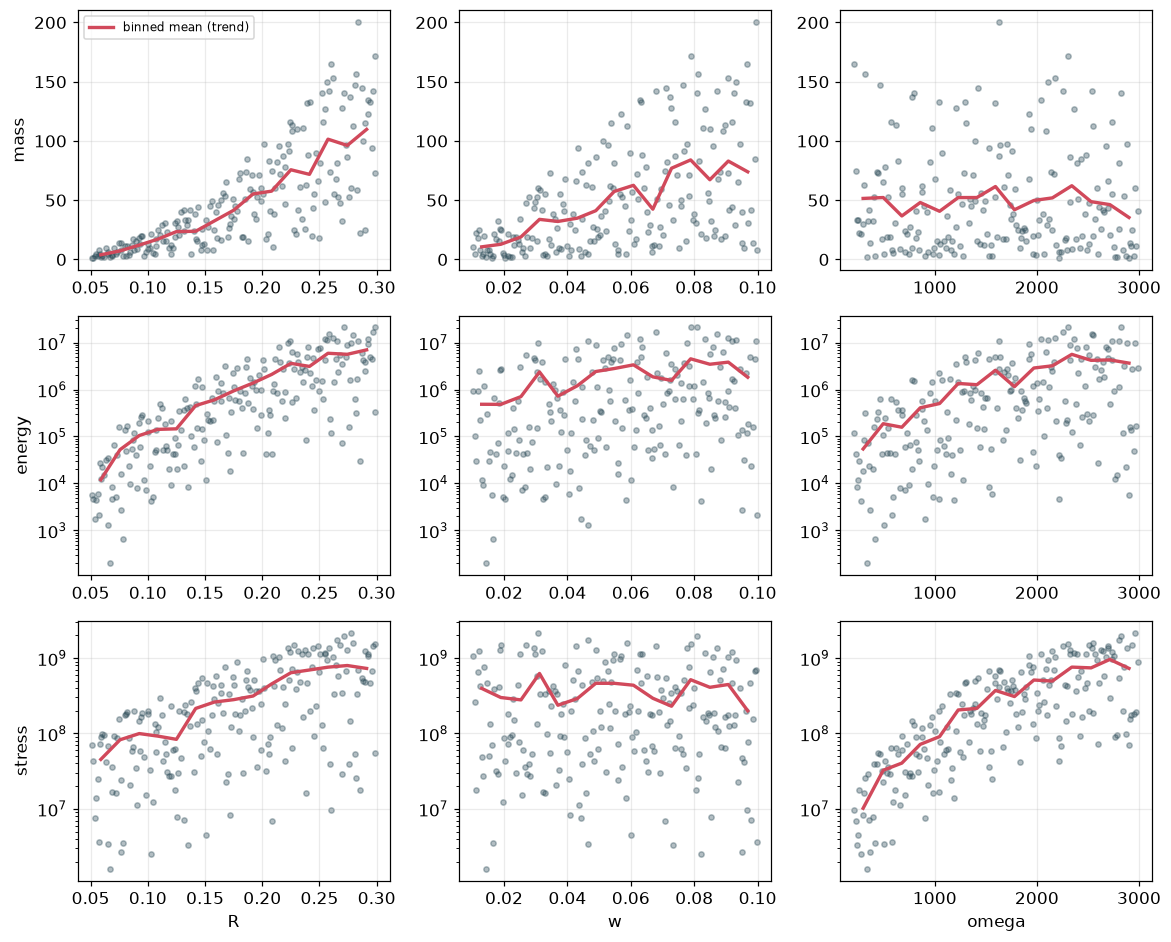

In [5]:
def bin_trend(x, y, n_bins=15):
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)
    centers, means = [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() >= 3:
            centers.append(x[mask].mean())
            means.append(y[mask].mean())
    return np.array(centers), np.array(means)


def plot_response_grid(X, responses, var_names, n_bins=15, log_y=("energy", "stress")):
    fig, axes = plt.subplots(len(responses), len(var_names),
                              figsize=(3.6 * len(var_names), 2.9 * len(responses)), squeeze=False)
    for row, (resp_name, resp_val) in enumerate(responses.items()):
        for col, var_name in enumerate(var_names):
            ax = axes[row][col]
            x = X[:, col]
            ax.scatter(x, resp_val, s=12, alpha=0.35, color=COLORS["sample"])
            cx, cy = bin_trend(x, resp_val, n_bins)
            ax.plot(cx, cy, color=COLORS["trend"], lw=2.2, label="binned mean (trend)")
            if resp_name in log_y:
                ax.set_yscale("log")
            if row == len(responses) - 1:
                ax.set_xlabel(var_name)
            if col == 0:
                ax.set_ylabel(resp_name)
    axes[0][0].legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    return fig, axes


plot_response_grid(X, responses, var_names)
plt.show()

---
## 4. Quantitative backup: Spearman rank correlation

A trend line can still be subtle to "eyeball", especially under noise. Spearman's rank
correlation $r_s$ between a variable and a response gives a single number: strongly positive
means *increasing*, strongly negative means *decreasing*, and close to zero means *flat / no
clear trend* -- confirming what the trend lines above suggest, without ever writing down a
derivative.

In [6]:
def monotonicity_table(X, responses, var_names, threshold=0.2):
    print(f"{'response':<8}{'variable':<9}{'spearman r':>12}   direction")
    directions = {}
    for resp_name, resp_val in responses.items():
        for col, var_name in enumerate(var_names):
            r, _ = spearmanr(X[:, col], resp_val)
            if r > threshold:
                direction = "increasing"
            elif r < -threshold:
                direction = "decreasing"
            else:
                direction = "flat / no clear trend"
            directions[(resp_name, var_name)] = (r, direction)
            print(f"{resp_name:<8}{var_name:<9}{r:12.3f}   {direction}")
    return directions


directions = monotonicity_table(X, responses, var_names)
assert directions[("mass", "omega")][1].startswith("flat")
assert directions[("stress", "w")][1].startswith("flat")
print("\nConfirmed: mass does not depend on omega, and stress does not depend on w.")

responsevariable   spearman r   direction
mass    R               0.844   increasing
mass    w               0.538   increasing
mass    omega          -0.028   flat / no clear trend
energy  R               0.785   increasing
energy  w               0.276   increasing
energy  omega           0.489   increasing
stress  R               0.576   increasing
stress  w               0.041   flat / no clear trend
stress  omega           0.762   increasing

Confirmed: mass does not depend on omega, and stress does not depend on w.


---
## 5. Apply MP1 to the objective variables $R$ and $w$

Both trend lines and the correlation table agree: `mass` increases with $R$ and with $w$, and
is flat in $\omega$. So $R$ and $w$ are the **objective variables** (MP1 applies to them);
$\omega$ is a **nonobjective variable** (MP2 applies to it, Section 6).

| variable | direction in `mass` | which sampled response(s) can supply a lower bound? | MP1 prediction |
|---|---|---|---|
| $R$ | increasing | `energy` increases with $R$; written as $\text{energy}\ge E_{\text{req}}$ this is a *nonincreasing*-type constraint in $R$ -- exactly what MP1 needs. `stress` also increases with $R$, but $\text{stress}\le\sigma_{\text{allow}}$ is an *upper*-bounding constraint, the wrong direction for MP1. | the energy requirement is the only candidate lower bound -> **critical** |
| $w$ | increasing | `energy` increases with $w$; `stress` is *flat* in $w$ (does not touch it at all). | the energy requirement is again the *only* constraint touching $w$ -> **critical** |

Because a single constraint ($\text{energy}\ge E_{\text{req}}$) is the only one that bounds
*both* $R$ and $w$ from below, MP1 says it must be **active** at the optimum -- we do not need
the closed-form expression to conclude this, only the sampled trend.

---
## 6. Apply MP2 to the nonobjective variable $\omega$

The `mass` vs. $\omega$ panel was flat: $\omega$ never appears in the objective. MP2 says it
must still be pinned down **both above and below**, or the optimizer could drive it to $0$ or
$\infty$ while `mass` stays indifferent.

* **Lower bound:** none of the sampled responses increase as $\omega$ shrinks, so nothing in
  the black box itself supplies a lower bound -- only the side bound $\omega \ge \omega_{\min}$
  does. This is exactly the kind of bound MP2 warns you not to forget even when the model
  "doesn't care".
* **Upper bound:** `energy` *increases* with $\omega$, so a larger $\omega$ *relaxes* the energy
  requirement, letting $R,w$ (and hence `mass`) shrink -- the optimizer wants $\omega$ as large
  as possible. Two candidates stop it: the side bound $\omega \le \omega_{\max}$, and `stress`,
  which also increases with $\omega$, giving $\text{stress}\le\sigma_{\text{allow}}$ as a
  second, physically-motivated upper bound.

> **Predict:** which of the two upper bounds -- the physical stress limit or the operational
> speed limit $\omega_{\max}$ -- do you expect will actually be the active one?

Since `stress` depends on $R$ and $\omega$ only through their product (a *tip speed* type
quantity $v_{\text{tip}}=R\omega$), the sampled stress trend implies a tip-speed limit -- a
well-known rule of thumb for real flywheel rotors.

In [7]:
# Combined bound implied by the sampled stress trend, expressed as a tip-speed limit.
v_tip = X[:, 0] * X[:, 2]
r_tip, _ = spearmanr(v_tip, responses["stress"])
print(f"spearman r(stress, R*omega) = {r_tip:.3f}  -> stress tracks the tip speed R*omega")

K_tip = np.sqrt(sigma_allow / (c_sigma * rho))
print(f"\nImplied tip-speed limit:  v_tip = R*omega  <~  {K_tip:.1f} m/s")
print("(Real steel flywheel rotors are typically limited to roughly 200-300 m/s tip speed --")
print(" our black-box requirement lands right in that realistic range.)")

spearman r(stress, R*omega) = 1.000  -> stress tracks the tip speed R*omega

Implied tip-speed limit:  v_tip = R*omega  <~  305.4 m/s
(Real steel flywheel rotors are typically limited to roughly 200-300 m/s tip speed --
 our black-box requirement lands right in that realistic range.)


---
## 7. Independent verification with a derivative-free black-box optimizer

Now forget the reasoning above and hand the problem to a numerical optimizer that only calls
`black_box()` -- exactly what you would do with a real, gradient-less simulator. We use
`scipy.optimize.differential_evolution`, a population-based, derivative-free method, with an
exterior penalty for constraint violation.

In [8]:
def penalized_mass(x, generator):
    resp = black_box(np.array([x]), generator)
    mass, energy, stress = resp["mass"][0], resp["energy"][0], resp["stress"][0]
    g_energy = max(0.0, E_req - energy) / E_req
    g_stress = max(0.0, stress - sigma_allow) / sigma_allow
    return mass * (1.0 + 50.0 * g_energy + 50.0 * g_stress)


rng_opt = np.random.default_rng(2024)
bounds = [(R_min, R_max), (w_min, w_max), (om_min, om_max)]
result = differential_evolution(lambda x: penalized_mass(x, rng_opt), bounds,
                                 seed=2024, maxiter=800, tol=1e-12, polish=True, popsize=30)

R_star, w_star, om_star = result.x
resp_star = black_box(np.array([result.x]), np.random.default_rng(1))
print(f"R*     = {R_star*100:.2f} cm    (bounds {R_min*100:.0f}-{R_max*100:.0f} cm)")
print(f"w*     = {w_star*1000:.2f} mm   (bounds {w_min*1000:.0f}-{w_max*1000:.0f} mm)")
print(f"omega* = {om_star:.1f} rad/s  (bounds {om_min:.0f}-{om_max:.0f} rad/s)")
print(f"mass*  = {resp_star['mass'][0]:.3f} kg")
print(f"energy* = {resp_star['energy'][0]:,.0f} J    vs required {E_req:,.0f} J")
print(f"stress* = {resp_star['stress'][0]/1e6:.1f} MPa  vs allowable {sigma_allow/1e6:.0f} MPa")

R*     = 10.16 cm    (bounds 5-30 cm)
w*     = 10.16 mm   (bounds 10-100 mm)
omega* = 2989.3 rad/s  (bounds 200-3000 rad/s)
mass*  = 2.588 kg
energy* = 60,276 J    vs required 60,000 J
stress* = 298.9 MPa  vs allowable 300 MPa


In [9]:
def design_activity(x, resp, tol=0.05):
    R, w, om = x
    residuals = {
        "energy >= E_req":       (resp["energy"][0] - E_req) / E_req,
        "stress <= sigma_allow": (sigma_allow - resp["stress"][0]) / sigma_allow,
        "R >= R_min":            (R - R_min) / (R_max - R_min),
        "R <= R_max":            (R_max - R) / (R_max - R_min),
        "w >= w_min":            (w - w_min) / (w_max - w_min),
        "w <= w_max":            (w_max - w) / (w_max - w_min),
        "omega >= om_min":       (om - om_min) / (om_max - om_min),
        "omega <= om_max":       (om_max - om) / (om_max - om_min),
    }
    print(f"{'constraint':<24}{'scaled residual':>16}   status")
    for name, r in residuals.items():
        status = "ACTIVE" if abs(r) < tol else "slack"
        print(f"{name:<24}{r:16.3f}   {status}")
    return residuals


activity = design_activity(result.x, resp_star)
assert abs(activity["energy >= E_req"]) < 0.10        # near-active, as MP1 predicted
assert abs(activity["stress <= sigma_allow"]) < 0.10   # near-active, as MP2 predicted
assert abs(activity["omega <= om_max"]) < 0.10         # omega pinned at its upper bound
print("\nMatches the monotonicity-based prediction: the energy requirement and the stress")
print("(tip-speed) limit are active, omega sits at its upper bound, and R keeps comfortable")
print("slack -- while w is only barely above w_min, a semi-active MP2-style side bound.")

constraint               scaled residual   status
energy >= E_req                    0.005   ACTIVE
stress <= sigma_allow              0.004   ACTIVE
R >= R_min                         0.206   slack
R <= R_max                         0.794   slack
w >= w_min                         0.002   ACTIVE
w <= w_max                         0.998   slack
omega >= om_min                    0.996   slack
omega <= om_max                    0.004   ACTIVE

Matches the monotonicity-based prediction: the energy requirement and the stress
(tip-speed) limit are active, omega sits at its upper bound, and R keeps comfortable
slack -- while w is only barely above w_min, a semi-active MP2-style side bound.


---
## 8. Explore: sample budget and noise vs. visual clarity

How many black-box calls do you actually need before the trend lines are trustworthy, and how
much simulator noise can you tolerate before a real trend starts to look flat? The lab below
regenerates the LHS sample and the scatter/trend grid for a chosen budget $p$ and noise level.

Suggested prompts:

1. Shrink $p$ down to 20-30. Do the flat panels (`mass` vs. $\omega$, `stress` vs. $w$) still
   look flat, or does the trend line start to wander?
2. Push the noise level up. At what point does the Spearman correlation for a genuinely
   sloped panel drop below the 0.2 threshold and get mis-classified as "flat"?
3. With a larger budget, does the flat-vs-sloped classification become more robust to noise?

In [10]:
def sampling_lab(p=200, noise=0.02, n_bins=15):
    generator = np.random.default_rng(2025)
    Xp = latin_hypercube(p, lo, hi, generator)
    respp = black_box(Xp, generator, noise=noise)
    plot_response_grid(Xp, respp, var_names, n_bins=n_bins)
    plt.show()
    monotonicity_table(Xp, respp, var_names)


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        sampling_lab,
        p=widgets.IntSlider(value=200, min=20, max=500, step=20, description="budget p"),
        noise=widgets.FloatSlider(value=0.02, min=0.0, max=0.15, step=0.01, description="noise"),
        n_bins=widgets.IntSlider(value=15, min=5, max=30, step=1, description="bins"),
    ))
else:
    sampling_lab()

interactive(children=(IntSlider(value=200, description='budget p', max=500, min=20, step=20), FloatSlider(valu…

---
## Takeaways

1. A Latin Hypercube sample lets you screen the monotonicity of a black-box model in one
   batch of runs, even though every sample varies all variables at once.
2. A scatter plot alone can look hopelessly noisy; a binned trend line (or any local-average
   smoother) recovers the marginal monotonic direction.
3. Spearman rank correlation gives a simple, derivative-free numerical backup for a visual
   monotonicity call, and a natural threshold for "flat / no clear trend".
4. MP1 still applies to objective variables identified as "increasing" or "decreasing" from
   the sampled trend -- you don't need a formula, only the sign of the trend.
5. MP2 still applies to variables the objective is flat in; a black-box screen is often the
   *only* practical way to discover that a variable is nonobjective in the first place.
6. A derivative-free optimizer (matching the black-box setting) can independently confirm
   which candidate constraints are actually active.

## Classroom exercises

1. Add a fourth design variable (e.g., a bore radius for a hub) that affects only one
   response, and predict its MP1/MP2 role from the trend plots before checking numerically.
2. Tighten $E_{\text{req}}$ or $\sigma_{\text{allow}}$ and re-run Section 7 -- does the
   activity table change the way MP1/MP2 would predict?
3. Lower the sample budget until the Section 4 asserts start failing; explain why in terms of
   sampling noise versus signal strength.
4. Replace the binned mean trend with a simple linear regression trend line and compare.